In [28]:
print("Hello IIITK")

Hello IIITK


# Import Libraries

In [29]:
import pandas as pd 
import numpy as np 

# Load German Credit Datasets

In [30]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

df = pd.read_csv(url, sep=' ', header=None) 

# First Five Rows

In [31]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [32]:
df.shape

(1000, 21)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1000 non-null   object
 1   1       1000 non-null   int64 
 2   2       1000 non-null   object
 3   3       1000 non-null   object
 4   4       1000 non-null   int64 
 5   5       1000 non-null   object
 6   6       1000 non-null   object
 7   7       1000 non-null   int64 
 8   8       1000 non-null   object
 9   9       1000 non-null   object
 10  10      1000 non-null   int64 
 11  11      1000 non-null   object
 12  12      1000 non-null   int64 
 13  13      1000 non-null   object
 14  14      1000 non-null   object
 15  15      1000 non-null   int64 
 16  16      1000 non-null   object
 17  17      1000 non-null   int64 
 18  18      1000 non-null   object
 19  19      1000 non-null   object
 20  20      1000 non-null   int64 
dtypes: int64(8), object(13)
memory usage: 164.2+ KB


In [34]:
df[20].value_counts()

20
1    700
2    300
Name: count, dtype: int64

In [35]:
X = df.drop(20, axis=1)

y = df[20]

print(X.shape)
print(y.shape)

(1000, 20)
(1000,)


In [36]:
X.select_dtypes(include=['object']).columns

Index([0, 2, 3, 5, 6, 8, 9, 11, 13, 14, 16, 18, 19], dtype='int64')

In [37]:
X.select_dtypes(include=['int64']).columns

Index([1, 4, 7, 10, 12, 15, 17], dtype='int64')

In [38]:
X[0].unique()

array(['A11', 'A12', 'A14', 'A13'], dtype=object)

In [39]:
from sklearn.preprocessing import OneHotEncoder

In [40]:
for col in X.select_dtypes(include=['object']).columns:
    print(f"Column {col}: {X[col].nunique()} unique values")

Column 0: 4 unique values
Column 2: 5 unique values
Column 3: 10 unique values
Column 5: 5 unique values
Column 6: 5 unique values
Column 8: 4 unique values
Column 9: 3 unique values
Column 11: 4 unique values
Column 13: 3 unique values
Column 14: 3 unique values
Column 16: 4 unique values
Column 18: 2 unique values
Column 19: 2 unique values


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [42]:
categorical_cols = X.select_dtypes(include=['object']).columns

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

In [44]:
X_processed = preprocessor.fit_transform(X)
print(X_processed.shape)

(1000, 48)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 48)
(200, 48)
(800,)
(200,)


In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

C:\Users\prakrithi jain\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

C:\Users\prakrithi jain\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 2 2 1 1 1 1 2 1 1]


In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[126  15]
 [ 25  34]]


In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.83      0.89      0.86       141
           2       0.69      0.58      0.63        59

    accuracy                           0.80       200
   macro avg       0.76      0.73      0.75       200
weighted avg       0.79      0.80      0.79       200



# Linear Regression

First 10 Predictions:
[1.44434671 1.53434372 1.6827243  1.33020788 0.99636266 1.4494296
 0.99283059 1.47324271 0.99449609 1.03674573]

Evaluation Metrics
MSE: 0.1566321607833235
RMSE: 0.3957678117069698
R² Score: 0.24687024506155297

Model Parameters
Intercept: 1.7115045363332508
Number of Coefficients: 48


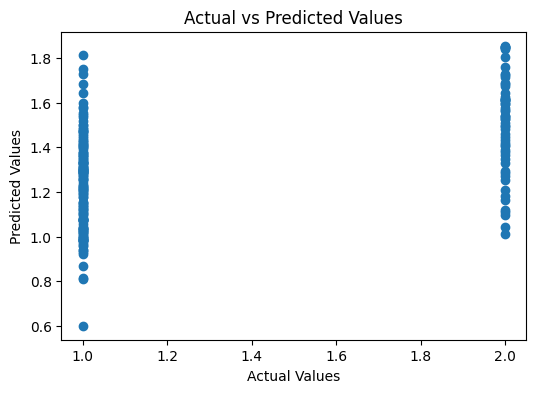

In [53]:
# ============================
# LINEAR REGRESSION MODEL
# ============================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Create Linear Regression Model
linear_model = LinearRegression()

# Train the Model
linear_model.fit(X_train, y_train)

# Make Predictions
y_pred_lr = linear_model.predict(X_test)

# Display First 10 Predictions
print("First 10 Predictions:")
print(y_pred_lr[:10])

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("\nEvaluation Metrics")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

# Model Parameters
print("\nModel Parameters")
print("Intercept:", linear_model.intercept_)
print("Number of Coefficients:", len(linear_model.coef_))

# Actual vs Predicted Plot
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()